# 01 - Dataset Validation for YOLOv8 Retail Theft Detection

**Purpose:** Comprehensive validation of YOLO format dataset for retail surveillance

**Objectives:**
- Verify YOLO label format correctness
- Detect missing label files or corrupt images
- Validate bounding box normalization (values in [0, 1])
- Detect empty, malformed, or invalid annotation files
- Generate detailed validation report
- Log all issues found

---

## 1. Setup and Imports

In [1]:
# Install required packages if needed
!pip install opencv-python pillow numpy pandas tqdm matplotlib seaborn --quiet

In [2]:
import os
import sys
import cv2
import json
import hashlib
import logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
from PIL import Image, ExifTags
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("All imports successful!")

All imports successful!


In [3]:
# Configuration
BASE_DIR = Path(r"c:/Users/shaho/OneDrive - Nile University/Desktop/AletrixGrad")
DATASET_DIR = BASE_DIR / "cc-tv-footage-annotation-b8-lcysc-b1-2"
OUTPUT_DIR = BASE_DIR / "outputs"
LOG_DIR = BASE_DIR / "logs"

# Create output directories
OUTPUT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

# Class definitions (from data.yaml)
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'normal',
    5: 'theft'
}
NUM_CLASSES = 6

# Supported image formats
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

print(f"Dataset Directory: {DATASET_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Class Names: {CLASS_NAMES}")

Dataset Directory: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\cc-tv-footage-annotation-b8-lcysc-b1-2
Output Directory: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs
Number of Classes: 6
Class Names: {0: 'Customer-Bagpack', 1: 'Product', 2: 'Product-Picked', 3: 'Shopping-Cart', 4: 'normal', 5: 'theft'}


## 2. Validation Classes and Functions

In [4]:
class DatasetValidator:
    """Comprehensive YOLO dataset validator for retail theft detection."""
    
    def __init__(self, dataset_path: Path, num_classes: int = 6):
        self.dataset_path = Path(dataset_path)
        self.num_classes = num_classes
        self.issues = defaultdict(list)
        self.stats = defaultdict(int)
        self.class_counts = defaultdict(int)
        self.bbox_stats = []
        self.image_stats = []
        
    def validate_image(self, image_path: Path) -> Tuple[bool, Optional[str], Optional[Tuple[int, int]]]:
        """Validate a single image file.
        
        Returns:
            Tuple of (is_valid, error_message, image_dimensions)
        """
        try:
            # Check file exists and is readable
            if not image_path.exists():
                return False, "File does not exist", None
            
            if image_path.stat().st_size == 0:
                return False, "File is empty (0 bytes)", None
            
            # Try to open with PIL
            try:
                with Image.open(image_path) as img:
                    img.verify()  # Verify image integrity
            except Exception as e:
                return False, f"PIL verification failed: {str(e)}", None
            
            # Re-open to get dimensions (verify() closes the file)
            with Image.open(image_path) as img:
                width, height = img.size
                mode = img.mode
            
            # Also try with OpenCV
            cv_img = cv2.imread(str(image_path))
            if cv_img is None:
                return False, "OpenCV failed to read image", None
            
            # Check for minimum dimensions
            if width < 10 or height < 10:
                return False, f"Image too small: {width}x{height}", (width, height)
            
            return True, None, (width, height)
            
        except Exception as e:
            return False, f"Unexpected error: {str(e)}", None
    
    def validate_label(self, label_path: Path, image_dims: Tuple[int, int]) -> Tuple[bool, List[str], List[Dict]]:
        """Validate a YOLO format label file.
        
        Returns:
            Tuple of (is_valid, list_of_errors, parsed_annotations)
        """
        errors = []
        annotations = []
        
        if not label_path.exists():
            return False, ["Label file does not exist"], []
        
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
        except Exception as e:
            return False, [f"Cannot read label file: {str(e)}"], []
        
        # Empty label file is valid (no objects in image)
        if len(lines) == 0:
            return True, [], []
        
        for line_num, line in enumerate(lines, 1):
            line = line.strip()
            if not line:  # Skip empty lines
                continue
            
            parts = line.split()
            
            # Check format: class_id x_center y_center width height
            if len(parts) != 5:
                errors.append(f"Line {line_num}: Expected 5 values, got {len(parts)}")
                continue
            
            try:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
            except ValueError as e:
                errors.append(f"Line {line_num}: Invalid numeric values - {str(e)}")
                continue
            
            # Validate class ID
            if class_id < 0 or class_id >= self.num_classes:
                errors.append(f"Line {line_num}: Invalid class ID {class_id} (expected 0-{self.num_classes-1})")
            
            # Validate bounding box coordinates (should be in [0, 1])
            bbox_errors = []
            if not (0 <= x_center <= 1):
                bbox_errors.append(f"x_center={x_center}")
            if not (0 <= y_center <= 1):
                bbox_errors.append(f"y_center={y_center}")
            if not (0 < width <= 1):
                bbox_errors.append(f"width={width}")
            if not (0 < height <= 1):
                bbox_errors.append(f"height={height}")
            
            if bbox_errors:
                errors.append(f"Line {line_num}: Out of range values: {', '.join(bbox_errors)}")
            
            # Check if bbox extends beyond image
            x_min = x_center - width / 2
            x_max = x_center + width / 2
            y_min = y_center - height / 2
            y_max = y_center + height / 2
            
            if x_min < -0.01 or x_max > 1.01 or y_min < -0.01 or y_max > 1.01:
                errors.append(f"Line {line_num}: Bbox extends beyond image boundaries")
            
            # Store annotation
            annotations.append({
                'class_id': class_id,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height,
                'area': width * height,
                'aspect_ratio': width / height if height > 0 else 0
            })
        
        is_valid = len(errors) == 0
        return is_valid, errors, annotations
    
    def validate_split(self, split_name: str) -> Dict[str, Any]:
        """Validate a dataset split (train/valid/test)."""
        split_path = self.dataset_path / split_name
        images_path = split_path / "images"
        labels_path = split_path / "labels"
        
        split_stats = {
            'total_images': 0,
            'valid_images': 0,
            'corrupt_images': 0,
            'missing_labels': 0,
            'invalid_labels': 0,
            'empty_labels': 0,
            'total_annotations': 0,
            'class_distribution': defaultdict(int),
            'issues': []
        }
        
        if not images_path.exists():
            logger.error(f"Images directory not found: {images_path}")
            return split_stats
        
        if not labels_path.exists():
            logger.error(f"Labels directory not found: {labels_path}")
            return split_stats
        
        # Get all images
        image_files = [f for f in images_path.iterdir() 
                       if f.suffix.lower() in IMAGE_EXTENSIONS]
        split_stats['total_images'] = len(image_files)
        
        logger.info(f"Validating {split_name}: {len(image_files)} images")
        
        for img_path in tqdm(image_files, desc=f"Validating {split_name}"):
            # Validate image
            img_valid, img_error, img_dims = self.validate_image(img_path)
            
            if not img_valid:
                split_stats['corrupt_images'] += 1
                split_stats['issues'].append({
                    'type': 'corrupt_image',
                    'file': str(img_path),
                    'error': img_error
                })
                self.issues['corrupt_images'].append(str(img_path))
                continue
            
            split_stats['valid_images'] += 1
            
            # Store image stats
            self.image_stats.append({
                'split': split_name,
                'file': img_path.name,
                'width': img_dims[0],
                'height': img_dims[1]
            })
            
            # Check for corresponding label
            label_path = labels_path / (img_path.stem + '.txt')
            
            if not label_path.exists():
                split_stats['missing_labels'] += 1
                split_stats['issues'].append({
                    'type': 'missing_label',
                    'file': str(img_path),
                    'expected_label': str(label_path)
                })
                self.issues['missing_labels'].append(str(img_path))
                continue
            
            # Validate label
            label_valid, label_errors, annotations = self.validate_label(label_path, img_dims)
            
            if len(annotations) == 0:
                split_stats['empty_labels'] += 1
            
            if not label_valid:
                split_stats['invalid_labels'] += 1
                split_stats['issues'].append({
                    'type': 'invalid_label',
                    'file': str(label_path),
                    'errors': label_errors
                })
                self.issues['invalid_labels'].append(str(label_path))
            
            # Count annotations
            split_stats['total_annotations'] += len(annotations)
            
            for ann in annotations:
                class_id = ann['class_id']
                if 0 <= class_id < self.num_classes:
                    split_stats['class_distribution'][class_id] += 1
                    self.class_counts[class_id] += 1
                
                # Store bbox stats
                self.bbox_stats.append({
                    'split': split_name,
                    'class_id': class_id,
                    'width': ann['width'],
                    'height': ann['height'],
                    'area': ann['area'],
                    'aspect_ratio': ann['aspect_ratio']
                })
        
        return split_stats
    
    def check_orphan_labels(self) -> List[str]:
        """Find label files without corresponding images."""
        orphan_labels = []
        
        for split in ['train', 'valid', 'test']:
            images_path = self.dataset_path / split / "images"
            labels_path = self.dataset_path / split / "labels"
            
            if not labels_path.exists():
                continue
            
            label_files = list(labels_path.glob("*.txt"))
            
            for label_path in label_files:
                # Check for any image with this stem
                has_image = False
                for ext in IMAGE_EXTENSIONS:
                    if (images_path / (label_path.stem + ext)).exists():
                        has_image = True
                        break
                
                if not has_image:
                    orphan_labels.append(str(label_path))
        
        return orphan_labels
    
    def validate_full_dataset(self) -> Dict[str, Any]:
        """Run complete validation on the entire dataset."""
        logger.info("="*60)
        logger.info("Starting Full Dataset Validation")
        logger.info("="*60)
        
        results = {
            'timestamp': datetime.now().isoformat(),
            'dataset_path': str(self.dataset_path),
            'splits': {},
            'summary': {},
            'class_distribution': {},
            'orphan_labels': [],
            'all_issues': []
        }
        
        # Validate each split
        for split in ['train', 'valid', 'test']:
            split_path = self.dataset_path / split
            if split_path.exists():
                results['splits'][split] = self.validate_split(split)
        
        # Check for orphan labels
        results['orphan_labels'] = self.check_orphan_labels()
        self.issues['orphan_labels'] = results['orphan_labels']
        
        # Calculate summary
        total_images = sum(s['total_images'] for s in results['splits'].values())
        valid_images = sum(s['valid_images'] for s in results['splits'].values())
        total_annotations = sum(s['total_annotations'] for s in results['splits'].values())
        corrupt_images = sum(s['corrupt_images'] for s in results['splits'].values())
        missing_labels = sum(s['missing_labels'] for s in results['splits'].values())
        invalid_labels = sum(s['invalid_labels'] for s in results['splits'].values())
        empty_labels = sum(s['empty_labels'] for s in results['splits'].values())
        
        results['summary'] = {
            'total_images': total_images,
            'valid_images': valid_images,
            'corrupt_images': corrupt_images,
            'missing_labels': missing_labels,
            'invalid_labels': invalid_labels,
            'empty_labels': empty_labels,
            'orphan_labels': len(results['orphan_labels']),
            'total_annotations': total_annotations,
            'validation_pass_rate': valid_images / total_images * 100 if total_images > 0 else 0
        }
        
        # Class distribution
        results['class_distribution'] = dict(self.class_counts)
        
        # Collect all issues
        for split_data in results['splits'].values():
            results['all_issues'].extend(split_data.get('issues', []))
        
        return results

## 3. Run Validation

In [5]:
# Initialize validator
validator = DatasetValidator(DATASET_DIR, num_classes=NUM_CLASSES)

# Run full validation
validation_results = validator.validate_full_dataset()

2026-01-18 21:51:32,756 - INFO - ============================================================
2026-01-18 21:51:32,759 - INFO - Starting Full Dataset Validation
2026-01-18 21:51:32,761 - INFO - ============================================================
2026-01-18 21:51:33,037 - INFO - Validating train: 2095 images
Validating train: 100%|██████████| 2095/2095 [00:48<00:00, 43.05it/s] 
2026-01-18 21:52:21,784 - INFO - Validating valid: 600 images
Validating valid: 100%|██████████| 600/600 [00:05<00:00, 114.80it/s]
2026-01-18 21:52:27,034 - INFO - Validating test: 303 images
Validating test: 100%|██████████| 303/303 [00:02<00:00, 112.26it/s]


## 4. Validation Report

In [6]:
# Print summary report
print("="*70)
print("DATASET VALIDATION REPORT")
print("="*70)
print(f"\nDataset: {DATASET_DIR.name}")
print(f"Validation Time: {validation_results['timestamp']}")

print("\n" + "-"*70)
print("SUMMARY")
print("-"*70)
summary = validation_results['summary']
print(f"Total Images:        {summary['total_images']:,}")
print(f"Valid Images:        {summary['valid_images']:,}")
print(f"Corrupt Images:      {summary['corrupt_images']:,}")
print(f"Missing Labels:      {summary['missing_labels']:,}")
print(f"Invalid Labels:      {summary['invalid_labels']:,}")
print(f"Empty Labels:        {summary['empty_labels']:,}")
print(f"Orphan Labels:       {summary['orphan_labels']:,}")
print(f"Total Annotations:   {summary['total_annotations']:,}")
print(f"Validation Pass Rate: {summary['validation_pass_rate']:.2f}%")

DATASET VALIDATION REPORT

Dataset: cc-tv-footage-annotation-b8-lcysc-b1-2
Validation Time: 2026-01-18T21:51:32.763321

----------------------------------------------------------------------
SUMMARY
----------------------------------------------------------------------
Total Images:        2,998
Valid Images:        2,998
Corrupt Images:      0
Missing Labels:      0
Invalid Labels:      0
Empty Labels:        1
Orphan Labels:       0
Total Annotations:   10,147
Validation Pass Rate: 100.00%


In [7]:
# Per-split statistics
print("\n" + "-"*70)
print("PER-SPLIT STATISTICS")
print("-"*70)

for split_name, split_data in validation_results['splits'].items():
    print(f"\n{split_name.upper()}:")
    print(f"  Total Images:      {split_data['total_images']:,}")
    print(f"  Valid Images:      {split_data['valid_images']:,}")
    print(f"  Corrupt Images:    {split_data['corrupt_images']:,}")
    print(f"  Missing Labels:    {split_data['missing_labels']:,}")
    print(f"  Invalid Labels:    {split_data['invalid_labels']:,}")
    print(f"  Empty Labels:      {split_data['empty_labels']:,}")
    print(f"  Annotations:       {split_data['total_annotations']:,}")


----------------------------------------------------------------------
PER-SPLIT STATISTICS
----------------------------------------------------------------------

TRAIN:
  Total Images:      2,095
  Valid Images:      2,095
  Corrupt Images:    0
  Missing Labels:    0
  Invalid Labels:    0
  Empty Labels:      1
  Annotations:       7,076

VALID:
  Total Images:      600
  Valid Images:      600
  Corrupt Images:    0
  Missing Labels:    0
  Invalid Labels:    0
  Empty Labels:      0
  Annotations:       2,097

TEST:
  Total Images:      303
  Valid Images:      303
  Corrupt Images:    0
  Missing Labels:    0
  Invalid Labels:    0
  Empty Labels:      0
  Annotations:       974


In [8]:
# Class distribution
print("\n" + "-"*70)
print("CLASS DISTRIBUTION")
print("-"*70)

class_dist = validation_results['class_distribution']
total_annots = sum(class_dist.values())

for class_id in sorted(class_dist.keys()):
    count = class_dist[class_id]
    percentage = count / total_annots * 100 if total_annots > 0 else 0
    class_name = CLASS_NAMES.get(class_id, f'Unknown-{class_id}')
    bar = '█' * int(percentage / 2)
    print(f"  {class_id}: {class_name:20s} {count:6,} ({percentage:5.1f}%) {bar}")


----------------------------------------------------------------------
CLASS DISTRIBUTION
----------------------------------------------------------------------
  0: Customer-Bagpack        780 (  7.7%) ███
  1: Product               1,061 ( 10.5%) █████
  2: Product-Picked        1,051 ( 10.4%) █████
  3: Shopping-Cart           212 (  2.1%) █
  4: normal                6,443 ( 63.5%) ███████████████████████████████
  5: theft                   600 (  5.9%) ██


In [9]:
# Issues found
print("\n" + "-"*70)
print("ISSUES FOUND")
print("-"*70)

all_issues = validation_results['all_issues']
if len(all_issues) == 0:
    print("\n  No issues found! Dataset is clean.")
else:
    # Group issues by type
    issues_by_type = defaultdict(list)
    for issue in all_issues:
        issues_by_type[issue['type']].append(issue)
    
    for issue_type, issues in issues_by_type.items():
        print(f"\n  {issue_type.upper()} ({len(issues)} found):")
        for issue in issues[:5]:  # Show first 5
            print(f"    - {issue.get('file', 'Unknown')}")
            if 'error' in issue:
                print(f"      Error: {issue['error']}")
            if 'errors' in issue:
                for err in issue['errors'][:3]:
                    print(f"      Error: {err}")
        if len(issues) > 5:
            print(f"    ... and {len(issues) - 5} more")


----------------------------------------------------------------------
ISSUES FOUND
----------------------------------------------------------------------

  No issues found! Dataset is clean.


In [10]:
# Orphan labels
if validation_results['orphan_labels']:
    print("\n" + "-"*70)
    print("ORPHAN LABELS (labels without images)")
    print("-"*70)
    for label in validation_results['orphan_labels'][:10]:
        print(f"  - {label}")
    if len(validation_results['orphan_labels']) > 10:
        print(f"  ... and {len(validation_results['orphan_labels']) - 10} more")

## 5. Visualization of Validation Results

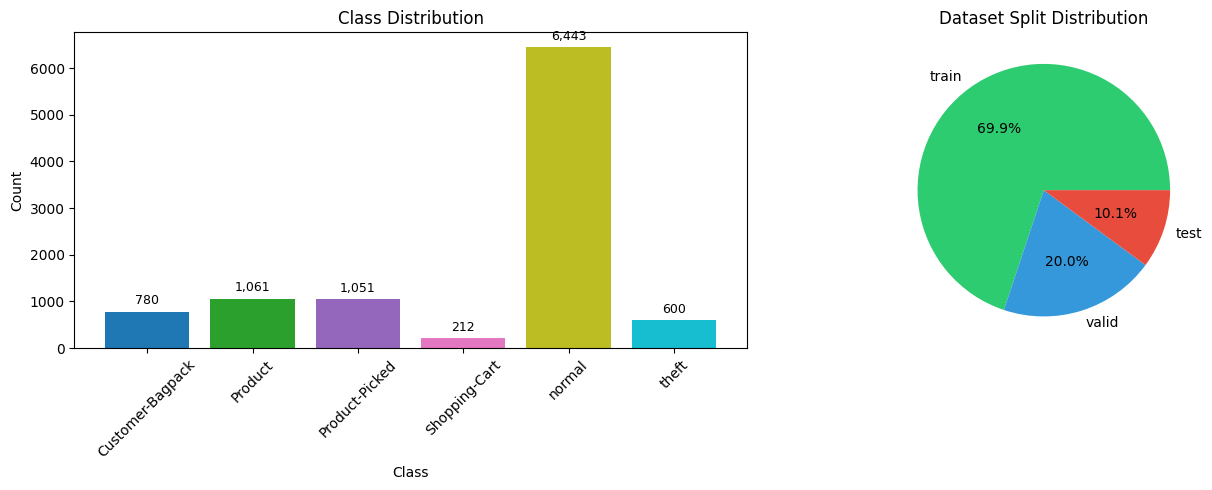


Visualization saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\validation_class_distribution.png


In [11]:
# Create visualization of class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
class_names_list = [CLASS_NAMES[i] for i in sorted(class_dist.keys())]
class_counts_list = [class_dist[i] for i in sorted(class_dist.keys())]

colors = plt.cm.tab10(np.linspace(0, 1, len(class_names_list)))
bars = axes[0].bar(class_names_list, class_counts_list, color=colors)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, class_counts_list):
    height = bar.get_height()
    axes[0].annotate(f'{count:,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

# Split distribution pie chart
split_sizes = [validation_results['splits'][s]['total_images'] 
               for s in ['train', 'valid', 'test'] 
               if s in validation_results['splits']]
split_labels = [s for s in ['train', 'valid', 'test'] if s in validation_results['splits']]
axes[1].pie(split_sizes, labels=split_labels, autopct='%1.1f%%', colors=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Dataset Split Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {OUTPUT_DIR / 'validation_class_distribution.png'}")

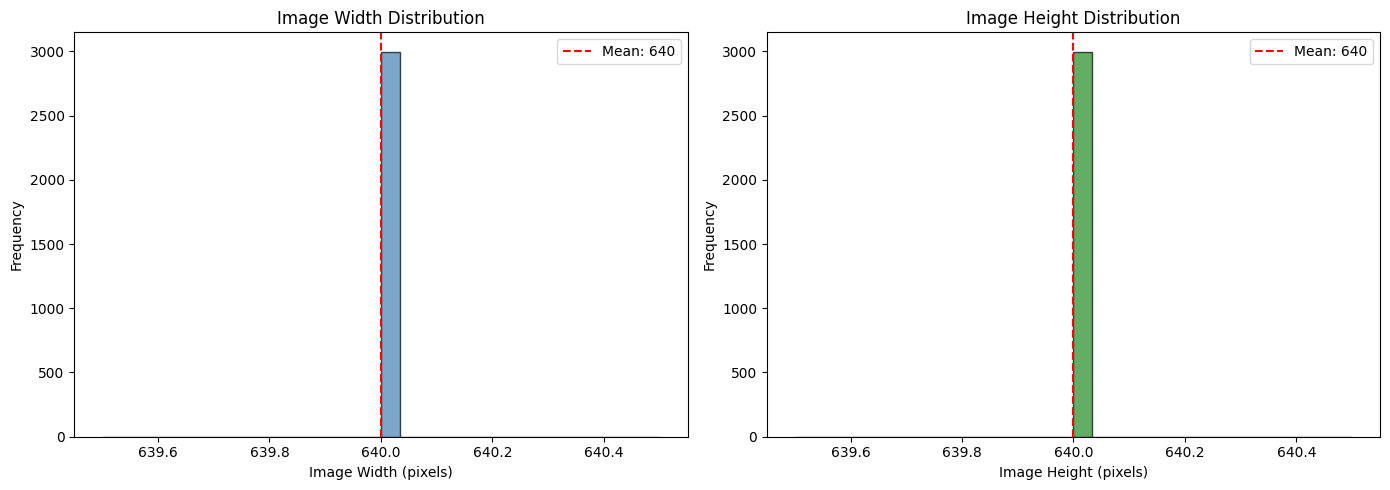


Image Statistics:
  Width  - Min: 640, Max: 640, Mean: 640.0
  Height - Min: 640, Max: 640, Mean: 640.0


In [12]:
# Image resolution distribution
if validator.image_stats:
    img_df = pd.DataFrame(validator.image_stats)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Width distribution
    axes[0].hist(img_df['width'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Image Width (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Image Width Distribution')
    axes[0].axvline(img_df['width'].mean(), color='red', linestyle='--', label=f'Mean: {img_df["width"].mean():.0f}')
    axes[0].legend()
    
    # Height distribution
    axes[1].hist(img_df['height'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Image Height (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Image Height Distribution')
    axes[1].axvline(img_df['height'].mean(), color='red', linestyle='--', label=f'Mean: {img_df["height"].mean():.0f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'validation_image_dimensions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nImage Statistics:")
    print(f"  Width  - Min: {img_df['width'].min()}, Max: {img_df['width'].max()}, Mean: {img_df['width'].mean():.1f}")
    print(f"  Height - Min: {img_df['height'].min()}, Max: {img_df['height'].max()}, Mean: {img_df['height'].mean():.1f}")

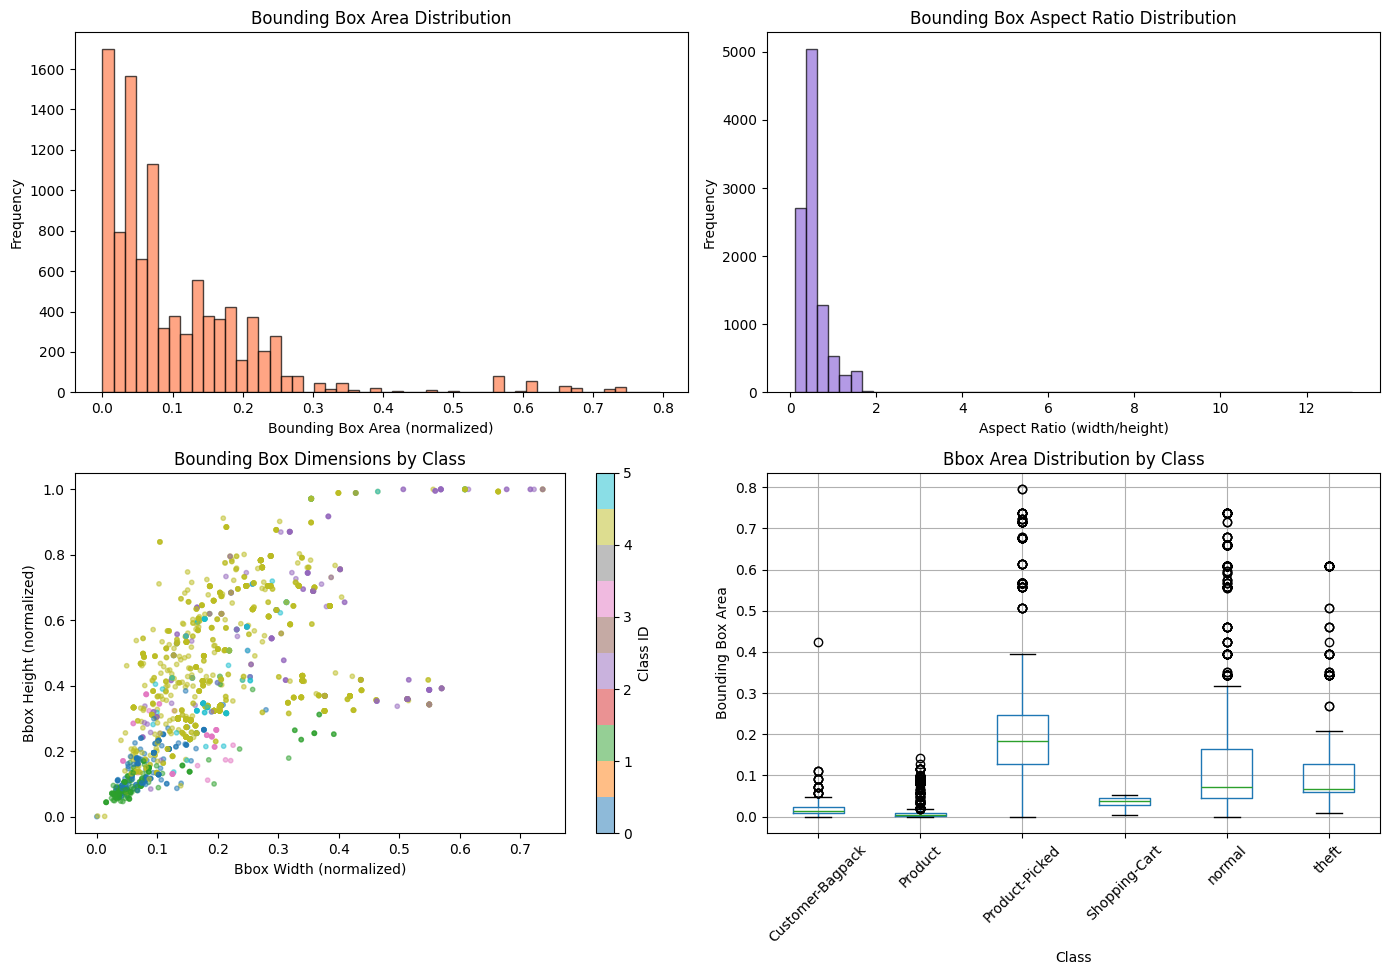


Bounding Box Statistics:
  Total Bboxes: 10,147
  Area - Min: 0.0000, Max: 0.7949, Mean: 0.1055
  Aspect Ratio - Min: 0.11, Max: 13.06, Mean: 0.56


In [13]:
# Bounding box statistics
if validator.bbox_stats:
    bbox_df = pd.DataFrame(validator.bbox_stats)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Bbox area distribution
    axes[0, 0].hist(bbox_df['area'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Bounding Box Area (normalized)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Bounding Box Area Distribution')
    
    # Aspect ratio distribution
    axes[0, 1].hist(bbox_df['aspect_ratio'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Aspect Ratio (width/height)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Bounding Box Aspect Ratio Distribution')
    
    # Width vs Height scatter
    sample_df = bbox_df.sample(min(2000, len(bbox_df)))  # Sample for performance
    scatter = axes[1, 0].scatter(sample_df['width'], sample_df['height'], 
                                  c=sample_df['class_id'], cmap='tab10', alpha=0.5, s=10)
    axes[1, 0].set_xlabel('Bbox Width (normalized)')
    axes[1, 0].set_ylabel('Bbox Height (normalized)')
    axes[1, 0].set_title('Bounding Box Dimensions by Class')
    plt.colorbar(scatter, ax=axes[1, 0], label='Class ID')
    
    # Area by class boxplot
    bbox_df['class_name'] = bbox_df['class_id'].map(CLASS_NAMES)
    bbox_df.boxplot(column='area', by='class_name', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Class')
    axes[1, 1].set_ylabel('Bounding Box Area')
    axes[1, 1].set_title('Bbox Area Distribution by Class')
    plt.suptitle('')  # Remove automatic title
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'validation_bbox_statistics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nBounding Box Statistics:")
    print(f"  Total Bboxes: {len(bbox_df):,}")
    print(f"  Area - Min: {bbox_df['area'].min():.4f}, Max: {bbox_df['area'].max():.4f}, Mean: {bbox_df['area'].mean():.4f}")
    print(f"  Aspect Ratio - Min: {bbox_df['aspect_ratio'].min():.2f}, Max: {bbox_df['aspect_ratio'].max():.2f}, Mean: {bbox_df['aspect_ratio'].mean():.2f}")

## 6. Save Validation Report

In [14]:
# Save detailed validation report as JSON
report_path = OUTPUT_DIR / 'validation_report.json'

# Convert defaultdicts to regular dicts for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, defaultdict):
        return dict(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

serializable_results = convert_to_serializable(validation_results)

with open(report_path, 'w') as f:
    json.dump(serializable_results, f, indent=2)

print(f"Validation report saved to: {report_path}")

Validation report saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\validation_report.json


In [15]:
# Save issues log
issues_log_path = LOG_DIR / 'validation_issues.log'

with open(issues_log_path, 'w') as f:
    f.write(f"Dataset Validation Issues Log\n")
    f.write(f"Generated: {datetime.now().isoformat()}\n")
    f.write(f"Dataset: {DATASET_DIR}\n")
    f.write("="*70 + "\n\n")
    
    for issue_type, issues in validator.issues.items():
        f.write(f"\n{issue_type.upper()} ({len(issues)} issues):\n")
        f.write("-"*50 + "\n")
        for issue in issues:
            f.write(f"  - {issue}\n")

print(f"Issues log saved to: {issues_log_path}")

Issues log saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\logs\validation_issues.log


In [16]:
# Save image and bbox statistics as CSV for further analysis
if validator.image_stats:
    img_stats_df = pd.DataFrame(validator.image_stats)
    img_stats_df.to_csv(OUTPUT_DIR / 'image_statistics.csv', index=False)
    print(f"Image statistics saved to: {OUTPUT_DIR / 'image_statistics.csv'}")

if validator.bbox_stats:
    bbox_stats_df = pd.DataFrame(validator.bbox_stats)
    bbox_stats_df.to_csv(OUTPUT_DIR / 'bbox_statistics.csv', index=False)
    print(f"Bbox statistics saved to: {OUTPUT_DIR / 'bbox_statistics.csv'}")

Image statistics saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\image_statistics.csv
Bbox statistics saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\bbox_statistics.csv


## 7. Validation Summary and Recommendations

In [17]:
# Final validation summary
print("="*70)
print("VALIDATION SUMMARY & RECOMMENDATIONS")
print("="*70)

summary = validation_results['summary']

# Overall status
if summary['validation_pass_rate'] >= 99:
    status = "EXCELLENT"
    status_color = "green"
elif summary['validation_pass_rate'] >= 95:
    status = "GOOD"
    status_color = "yellow"
else:
    status = "NEEDS ATTENTION"
    status_color = "red"

print(f"\nOverall Dataset Quality: {status}")
print(f"Validation Pass Rate: {summary['validation_pass_rate']:.2f}%")

# Recommendations
print("\n" + "-"*70)
print("RECOMMENDATIONS:")
print("-"*70)

recommendations = []

if summary['corrupt_images'] > 0:
    recommendations.append(f"- Remove or replace {summary['corrupt_images']} corrupt images")

if summary['missing_labels'] > 0:
    recommendations.append(f"- Create labels for {summary['missing_labels']} images or remove images without labels")

if summary['invalid_labels'] > 0:
    recommendations.append(f"- Fix {summary['invalid_labels']} invalid label files")

if summary['orphan_labels'] > 0:
    recommendations.append(f"- Remove {summary['orphan_labels']} orphan label files")

# Class imbalance check
class_counts = list(validation_results['class_distribution'].values())
if class_counts:
    max_count = max(class_counts)
    min_count = min(class_counts)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    if imbalance_ratio > 10:
        recommendations.append(f"- CRITICAL: High class imbalance (ratio: {imbalance_ratio:.1f}x). Consider oversampling minority classes.")
    elif imbalance_ratio > 5:
        recommendations.append(f"- WARNING: Moderate class imbalance (ratio: {imbalance_ratio:.1f}x). Consider data augmentation for minority classes.")

if not recommendations:
    recommendations.append("- Dataset is clean and ready for training!")

for rec in recommendations:
    print(rec)

print("\n" + "="*70)
print("Validation complete!")
print("="*70)

VALIDATION SUMMARY & RECOMMENDATIONS

Overall Dataset Quality: EXCELLENT
Validation Pass Rate: 100.00%

----------------------------------------------------------------------
RECOMMENDATIONS:
----------------------------------------------------------------------
- CRITICAL: High class imbalance (ratio: 30.4x). Consider oversampling minority classes.

Validation complete!


---

## Next Steps

After validation, proceed to:
1. **02_dataset_cleaning.ipynb** - Clean and fix identified issues
2. **03_dataset_analysis.ipynb** - Deep analysis and visualization

---